In [1]:
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
import matplotlib.pyplot as plt
import harmonypy as hm

In [2]:
adata = sc.read("../results/adata/07-filter.h5ad")

In [3]:
adata.X = adata.layers["soupx_rounded"].copy()

In [4]:
adata.obs["sample"].value_counts()

sample
D5_C    4423
D5_B    3834
D5_A    3416
D7_C    3270
D2_C    3048
D7_D    2389
D0_B    2182
D2_D    1550
D0_A    1467
Name: count, dtype: int64

## Filter Genes

In [5]:
print(f"{len(adata.var)} genes before filtering")
sc.pp.filter_genes(adata, min_counts=10)
print(f"{len(adata.var)} genes after filtering")

78334 genes before filtering
32253 genes after filtering


## Remove detected doublets
See what results look like without removing first.

In [6]:
adata = adata[adata.obs["scdblfinder_class"] == 1].copy()

## Normalization 
Normalize data with shifted logarithm method

In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

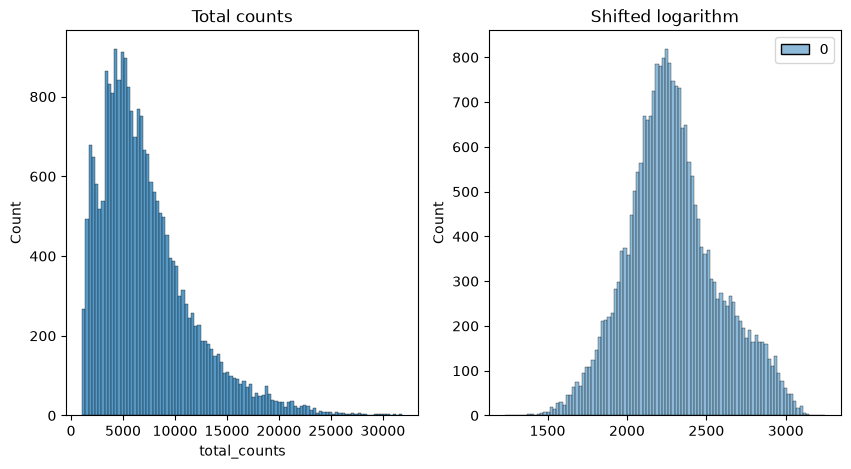

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.X.sum(1), bins=100, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

## Feature Selection
See Zappia et al. for benchmarks - https://doi.org/10.1038/s41592-025-02624-3

In [9]:
sc.pp.highly_variable_genes(adata, layer="soupx_rounded", n_top_genes=4000, flavor="seurat_v3", batch_key="sample", span=0.5)

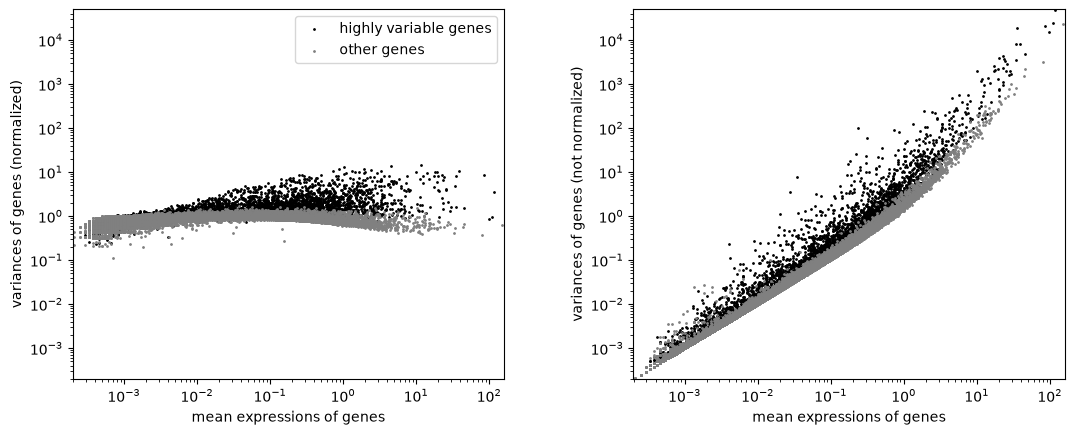

In [10]:
sc.pl.highly_variable_genes(adata, log=True)

## Dimensionality Reduction

In [11]:
sc.pp.pca(adata, svd_solver="arpack", mask_var="highly_variable")

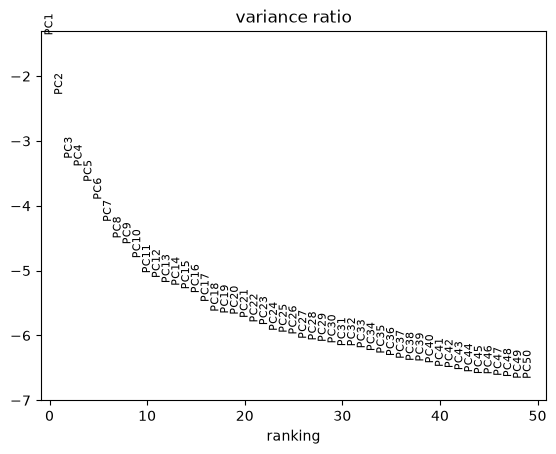

In [12]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

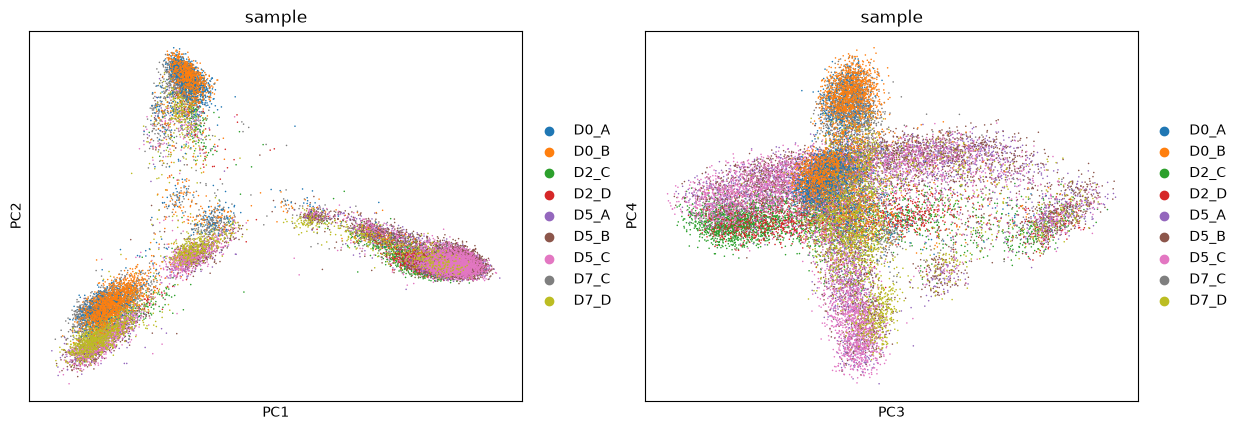

In [13]:
sc.pl.pca_scatter(adata, color="sample", components=["1,2", "3,4"])

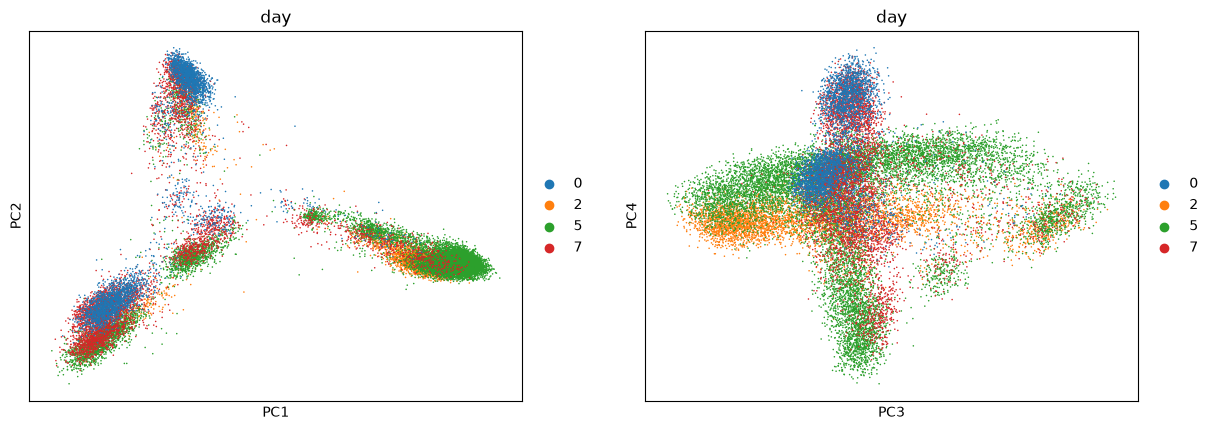

In [14]:
sc.pl.pca_scatter(adata, color="day", components=["1,2", "3,4"])

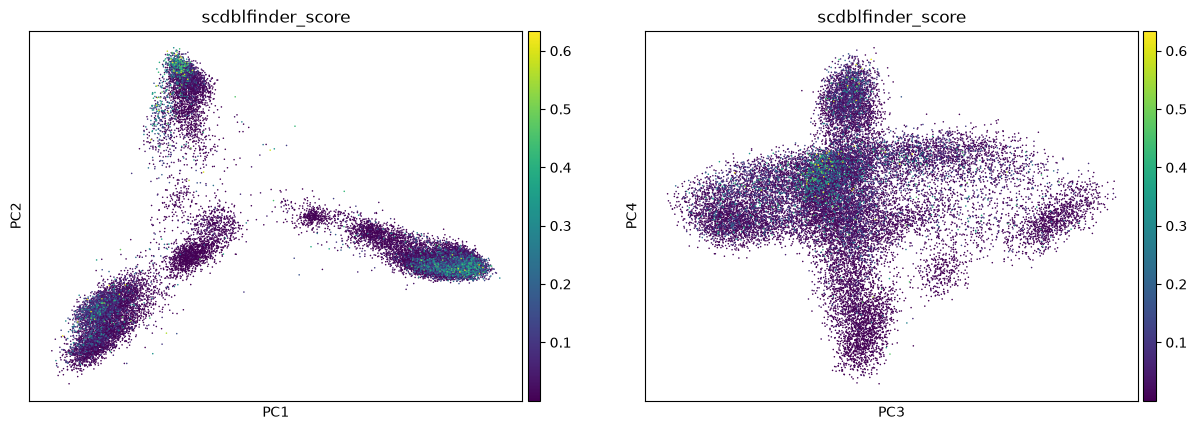

In [15]:
sc.pl.pca_scatter(adata, color="scdblfinder_score", components=["1,2", "3,4"])

## TSNE

In [16]:
# sc.tl.tsne(adata)

In [17]:
# adata

In [18]:
# sc.pl.tsne(adata, ncols=3, color=["sample", "day", "total_counts", "pct_counts_mt", "scdblfinder_score"])

## UMAP

In [19]:
sc.pp.neighbors(adata, n_pcs=40)
# sc.tl.umap(adata)

In [20]:
# sc.pl.umap(adata, ncols=3, color=["sample", "day", "total_counts", "pct_counts_mt", "scdblfinder_score"])

In [21]:
# sc.pl.umap(adata, edges=True, edges_width=0.1)

## Batch correction

In [22]:
harmony_out = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "sample", max_iter_harmony=30)
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr

2026-06-29 10:00:36,022 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-06-29 10:00:36,025 - harmonypy - INFO -   Parameters:
2026-06-29 10:00:36,026 - harmonypy - INFO -     max_iter_harmony: 30
2026-06-29 10:00:36,027 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-29 10:00:36,029 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-29 10:00:36,031 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-29 10:00:36,031 - harmonypy - INFO -     nclust: 100
2026-06-29 10:00:36,032 - harmonypy - INFO -     block_size: 0.05
2026-06-29 10:00:36,042 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-06-29 10:00:36,043 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-06-29 10:00:36,044 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-29 10:00:36,045 - harmonypy - INFO -     verbose: True
2026-06-29 10:00:36,045 - harmonypy - INFO -     random_state: 0
2026-06-29 10:00:36,046 - harmonypy - INFO -   Data: 50 PCs × 23906 cells


#### Corrected PCA

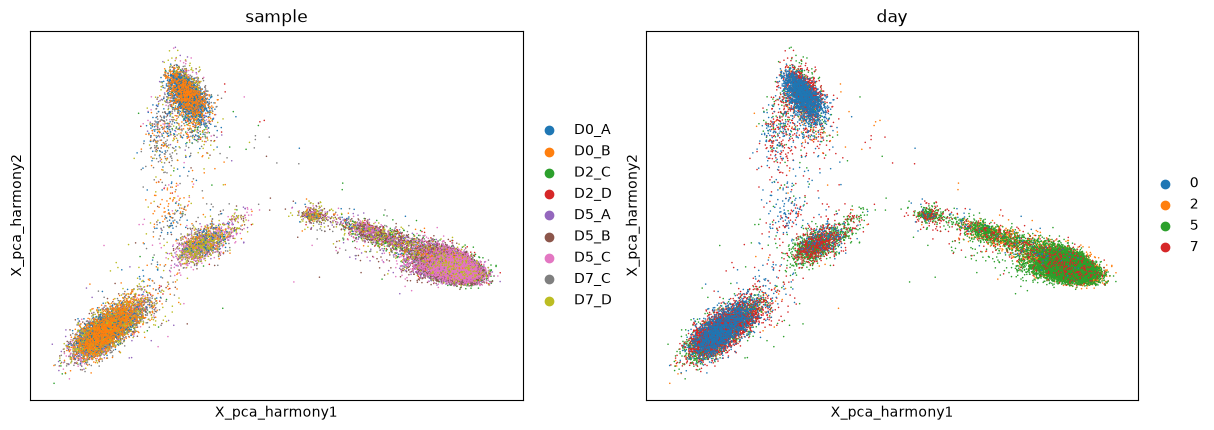

In [23]:
sc.pl.embedding(adata, basis="X_pca_harmony", color=["sample", "day"])

### Corrected TSNE

In [24]:
# sc.tl.tsne(adata, use_rep="X_pca_harmony")

In [25]:
# sc.pl.tsne(adata, color=["sample", "day"])

#### Corrected UMAP

In [26]:
sc.pp.neighbors(adata, n_pcs=40, use_rep='X_pca_harmony')
sc.tl.umap(adata)

In [27]:
# sc.pl.umap(adata, ncols=3, color=["sample", "day"])

In [28]:
adata.write("../results/adata/08-preprocess.h5ad")